# HOG-based Person Re-ID Pipeline (Optimized)
## Dataset: Market-1501

# Cell 1 — Import & Config

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from skimage.feature import hog

# ============================================================
# CONFIG
# ============================================================

IMG_H = 128
IMG_W = 64

RGB_BINS = 8

TOP_K = 10

DATASET_DIR = 'Market-1501-v15.09.15'

QUERY_DIR = os.path.join(DATASET_DIR, 'query')

GALLERY_DIR = os.path.join(DATASET_DIR, 'bounding_box_test')

# ============================================================
# CHECK DATASET
# ============================================================

assert os.path.exists(DATASET_DIR), \
    f"Khong tim thay dataset: {DATASET_DIR}"

assert os.path.exists(QUERY_DIR), \
    "Khong tim thay QUERY_DIR"

assert os.path.exists(GALLERY_DIR), \
    "Khong tim thay GALLERY_DIR"

q_count = len([
    f for f in os.listdir(QUERY_DIR)
    if f.endswith('.jpg')
])

g_count = len([
    f for f in os.listdir(GALLERY_DIR)
    if f.endswith('.jpg')
])

print("✅ Dataset loaded")

print(f"Query images  : {q_count}")

print(f"Gallery images: {g_count}")

✅ Dataset loaded
Query images  : 3368
Gallery images: 19732


# Cell 2 — Preprocess

In [22]:
# ============================================================
# PREPROCESS
# ============================================================

def preprocess(img):

    img = cv2.resize(
        img,
        (IMG_W, IMG_H),
        interpolation=cv2.INTER_LINEAR
    )

    # ========================================================
    # CLAHE on Y channel
    # ========================================================

    ycrcb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2YCrCb
    )

    y, cr, cb = cv2.split(ycrcb)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    y = clahe.apply(y)

    ycrcb = cv2.merge([y, cr, cb])

    img = cv2.cvtColor(
        ycrcb,
        cv2.COLOR_YCrCb2BGR
    )

    # ========================================================
    # FLOAT NORMALIZE
    # ========================================================

    img = img.astype(np.float32) / 255.0

    img = np.clip(img, 0, 1)

    return img

# Cell 3 — RGB Histogram

In [23]:
def extract_rgb_hist(img):

    """
    RGB Histogram Feature
    img range: [0,1]
    """

    hist = cv2.calcHist(
        [img],
        [0, 1, 2],
        None,
        [RGB_BINS, RGB_BINS, RGB_BINS],
        [0, 1, 0, 1, 0, 1]
    )

    hist = hist.flatten().astype(np.float32)

    # ========================================================
    # L1 NORMALIZE
    # ========================================================

    hist /= (hist.sum() + 1e-8)

    return hist

# Cell 4 — HOG Feature

In [24]:
def extract_hog_feature(gray):

    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        transform_sqrt=True,
        feature_vector=True
    )

    return feat.astype(np.float32)

# Cell 5 — Final Feature Extraction

In [25]:
# ============================================================
# FINAL FEATURE
# ============================================================

def extract_feature(img):

    img = preprocess(img)

    rgb_feat = extract_rgb_hist(img)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    hog_feat = extract_hog_feature(gray)

    feat = np.concatenate([
        rgb_feat,
        hog_feat
    ]).astype(np.float32)

    # ========================================================
    # GLOBAL L2 NORMALIZE
    # ========================================================

    norm = np.linalg.norm(feat)

    if norm > 0:
        feat /= norm

    return feat

# Cell 6 — HOG Visualization

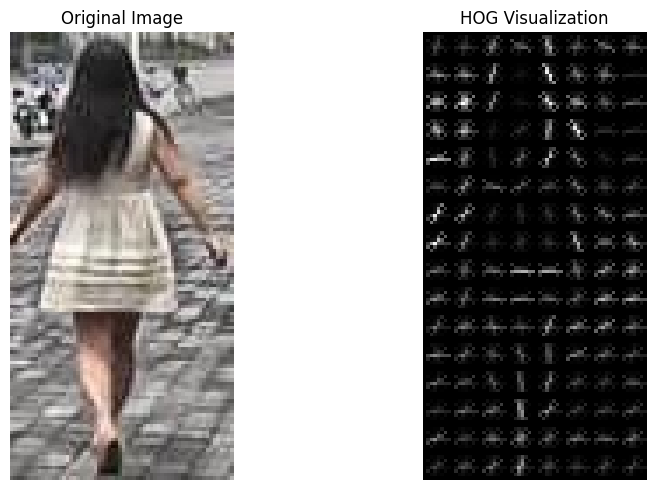

HOG dimension: 3780


In [26]:
sample_file = sorted([
    f for f in os.listdir(QUERY_DIR)
    if f.endswith('.jpg')
])[0]

sample_path = os.path.join(
    QUERY_DIR,
    sample_file
)

sample_bgr = cv2.imread(sample_path)

img = preprocess(sample_bgr)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

feat, hog_img = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    transform_sqrt=True,
    visualize=True,
    feature_vector=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    cv2.cvtColor(
        (img * 255).astype(np.uint8),
        cv2.COLOR_BGR2RGB
    )
)

axes[0].set_title("Original Image")

axes[0].axis('off')

axes[1].imshow(
    hog_img,
    cmap='gray'
)

axes[1].set_title("HOG Visualization")

axes[1].axis('off')

plt.tight_layout()

plt.show()

print("HOG dimension:", len(feat))

# Cell 7 — Dataset Loader

In [38]:
# Cell 7 — Dataset Loader

# ============================================================
# PARSE PERSON ID
# ============================================================

def parse_pid(fname):

    pid_str = fname.split('_')[0]

    return int(pid_str)


# ============================================================
# PARSE CAMERA ID
# ============================================================

def parse_camid(fname):

    try:
        return int(fname.split('_c')[1][0])

    except:
        return -1


# ============================================================
# LOAD FEATURES
# ============================================================

def load_features(img_dir, desc=''):

    files = sorted([
        f for f in os.listdir(img_dir)
        if f.endswith('.jpg')
    ])

    feats = []
    pids = []
    camids = []
    fnames = []

    for fname in tqdm(files, desc=desc):

        path = os.path.join(
            img_dir,
            fname
        )

        # ====================================================
        # READ IMAGE
        # ====================================================

        img = cv2.imread(path)

        if img is None:
            continue

        # ====================================================
        # EXTRACT FEATURE
        # ====================================================

        feat = extract_feature(img)

        feats.append(feat)

        pids.append(parse_pid(fname))

        camids.append(parse_camid(fname))

        fnames.append(fname)

    return (
        np.array(feats, dtype=np.float32),
        np.array(pids),
        np.array(camids),
        fnames
    )

# Cell 8 — Extract Features

In [39]:
print("🔵 Extracting Query Features...")

q_feats, q_pids, q_camids, q_fnames = load_features(
    QUERY_DIR,
    desc='Query'
)

print()

print("🔵 Extracting Gallery Features...")

g_feats, g_pids, g_camids, g_fnames = load_features(
    GALLERY_DIR,
    desc='Gallery'
)

print()

print("Query shape  :", q_feats.shape)

print("Gallery shape:", g_feats.shape)

🔵 Extracting Query Features...


Query: 100%|██████████| 3368/3368 [00:07<00:00, 455.64it/s]



🔵 Extracting Gallery Features...


Gallery: 100%|██████████| 19732/19732 [00:57<00:00, 342.36it/s]



Query shape  : (3368, 4292)
Gallery shape: (19732, 4292)


In [40]:
# ============================================================
# DETERMINISTIC TEST
# ============================================================

print("🧪 Deterministic Test")

test_path = os.path.join(
    GALLERY_DIR,
    g_fnames[0]
)

img = cv2.imread(test_path)

feat1 = extract_feature(img)

feat2 = extract_feature(img)

sim = np.dot(feat1, feat2)

print()

print("Image:")
print(g_fnames[0])

print()

print("Self Similarity:")
print(sim)

🧪 Deterministic Test

Image:
-1_c1s1_000401_03.jpg

Self Similarity:
1.0


# Cell 9 — Cosine Similarity Matrix

In [41]:
print("🟡 Computing Similarity Matrix...")

# ============================================================
# Cosine similarity because features already L2-normalized
# ============================================================

sim_matrix = np.matmul(
    q_feats,
    g_feats.T
).astype(np.float32)

print()

print("Similarity matrix:", sim_matrix.shape)

print("Min :", sim_matrix.min())

print("Max :", sim_matrix.max())

print("Mean:", sim_matrix.mean())

🟡 Computing Similarity Matrix...

Similarity matrix: (3368, 19732)
Min : 0.25398076
Max : 0.9567104
Mean: 0.6657447


# Cell 10 — Evaluation

In [42]:
def evaluate(sim_matrix, q_pids, g_pids):

    nq = len(q_pids)

    rank1 = 0
    rank5 = 0
    rank10 = 0

    ap_list = []

    for i in tqdm(range(nq), desc='Evaluating'):

        order = np.argsort(
            -sim_matrix[i]
        )

        matches = (
            g_pids[order] == q_pids[i]
        ).astype(np.int32)

        # ====================================================
        # Rank-k
        # ====================================================

        if matches[:1].sum() > 0:
            rank1 += 1

        if matches[:5].sum() > 0:
            rank5 += 1

        if matches[:10].sum() > 0:
            rank10 += 1

        # ====================================================
        # AP
        # ====================================================

        num_rel = matches.sum()

        if num_rel == 0:
            ap_list.append(0)
            continue

        tmp = matches.cumsum()

        precision = tmp / (
            np.arange(len(matches)) + 1
        )

        ap = (
            precision * matches
        ).sum() / num_rel

        ap_list.append(ap)

    print()

    print("================================================")

    print(f"Rank-1 : {rank1 / nq * 100:.2f}%")

    print(f"Rank-5 : {rank5 / nq * 100:.2f}%")

    print(f"Rank-10: {rank10 / nq * 100:.2f}%")

    print(f"mAP    : {np.mean(ap_list) * 100:.2f}%")

    print("================================================")

# Cell 11 — Run Evaluation

In [43]:
evaluate(
    sim_matrix,
    q_pids,
    g_pids
)

Evaluating: 100%|██████████| 3368/3368 [00:01<00:00, 1949.37it/s]


Rank-1 : 73.31%
Rank-5 : 78.15%
Rank-10: 80.20%
mAP    : 7.25%


In [44]:
# ============================================================
# EXACT IMAGE RETRIEVAL TEST
# ============================================================

idx = 0

query_feat = g_feats[idx]

sims = np.dot(
    g_feats,
    query_feat
)

top1 = np.argmax(sims)

print()

print("QUERY IMAGE:")
print(g_fnames[idx])

print()

print("TOP-1 RETRIEVED:")
print(g_fnames[top1])

print()

print("SIMILARITY:")
print(float(sims[top1]))


QUERY IMAGE:
-1_c1s1_000401_03.jpg

TOP-1 RETRIEVED:
-1_c1s1_000401_03.jpg

SIMILARITY:
0.9999999403953552


# Cell 12 — Top-K Retrieval Demo

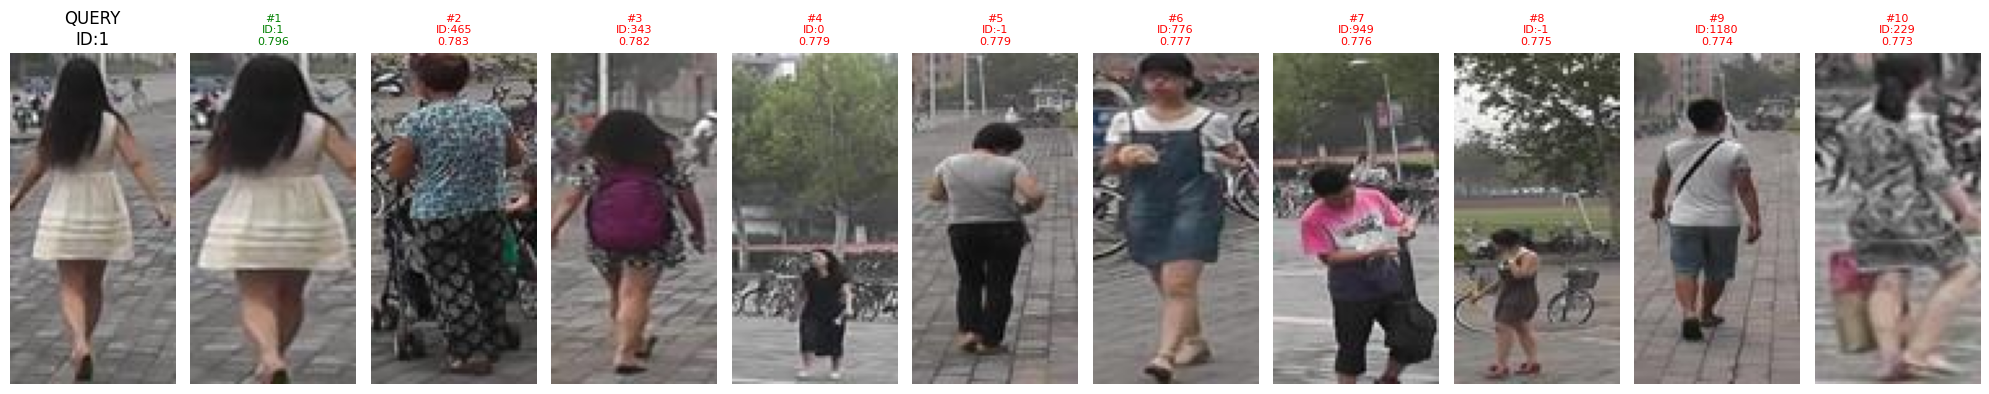

In [45]:
QUERY_INDEX = 0

sorted_idx = np.argsort(
    -sim_matrix[QUERY_INDEX]
)[:TOP_K]

query_img = cv2.cvtColor(
    cv2.imread(
        os.path.join(
            QUERY_DIR,
            q_fnames[QUERY_INDEX]
        )
    ),
    cv2.COLOR_BGR2RGB
)

fig, axes = plt.subplots(
    1,
    TOP_K + 1,
    figsize=(20, 5)
)

# ============================================================
# QUERY
# ============================================================

axes[0].imshow(query_img)

axes[0].set_title(
    f'QUERY\nID:{q_pids[QUERY_INDEX]}'
)

axes[0].axis('off')

# ============================================================
# TOP-K
# ============================================================

for i, g_idx in enumerate(sorted_idx):

    gallery_img = cv2.cvtColor(
        cv2.imread(
            os.path.join(
                GALLERY_DIR,
                g_fnames[g_idx]
            )
        ),
        cv2.COLOR_BGR2RGB
    )

    correct = (
        g_pids[g_idx] == q_pids[QUERY_INDEX]
    )

    color = 'green' if correct else 'red'

    sim = sim_matrix[
        QUERY_INDEX,
        g_idx
    ]

    axes[i + 1].imshow(gallery_img)

    axes[i + 1].set_title(
        f'#{i+1}\n'
        f'ID:{g_pids[g_idx]}\n'
        f'{sim:.3f}',
        color=color,
        fontsize=8
    )

    axes[i + 1].axis('off')

plt.tight_layout()

plt.show()

# SAVE FEATURES

In [47]:
print("💾 Saving gallery features...")

np.savez_compressed(
    'gallery_features.npz',

    g_feats=g_feats,

    g_pids=g_pids,

    g_camids=g_camids,

    g_fnames=np.array(g_fnames)
)

print("✅ Saved: gallery_features.npz")

💾 Saving gallery features...
✅ Saved: gallery_features.npz
